In [1]:
import glob 
import pandas as pd 
# set the local file path
file_path=r"/kaggle/input/top-9-classes/top_9_classes.csv"
df=pd.read_csv(file_path)
print(df.head())


   Destination Port  Flow Duration  Total Fwd Packets  Total Backward Packets  \
0             54865              3                  2                       0   
1             55054            109                  1                       1   
2             55055             52                  1                       1   
3             46236             34                  1                       1   
4             54863              3                  2                       0   

   Total Length of Fwd Packets  Total Length of Bwd Packets  \
0                           12                            0   
1                            6                            6   
2                            6                            6   
3                            6                            6   
4                           12                            0   

   Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  \
0                      6                      6            

In [5]:
!pip uninstall -y scikit-learn
!pip install scikit-learn

Found existing installation: scikit-learn 1.7.1
Uninstalling scikit-learn-1.7.1:
  Successfully uninstalled scikit-learn-1.7.1
  Using cached scikit_learn-1.7.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.7.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.1 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.1 which is incompatible.


In [3]:
!pip install torch_geometric

In [6]:
# --- Q1-READY CODE BLOCK 1: Initial Setup, Data Loading, and Basic Cleaning ---

# 1. Essential Library Imports (Consolidated for clarity and Q1 standard libraries)
import pandas as pd
import numpy as np
import os # For robust file path handling
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal # For Bayesian Layer
import matplotlib.pyplot as plt # For plotting
import seaborn as sns # For enhanced plotting
import warnings # To manage warnings

# Scikit-Learn specific imports
from sklearn.model_selection import train_test_split, GridSearchCV # GridSearchCV for hyperparameter tuning
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve, precision_recall_curve # More comprehensive metrics
from sklearn.decomposition import PCA # For PCA-based feature selection

# Imbalanced Data Handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler # Explicitly for Natural Balancing
from collections import Counter # To display class distributions

# For Boruta (Install if not already present: !pip install boruta)
from boruta import BorutaPy

# For GNN (Install if not already present in Colab:
# Refer to https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html
# Example for Colab:
# import torch
# print(torch.__version__) # e.g., 2.3.0+cu121
# !pip install torch_geometric
# !pip install torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
# !pip install torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
from torch_geometric.nn import GCNConv # Specific GNN layer
from torch_geometric.utils import from_scipy_sparse_matrix # For graph conversion from adjacency matrix
from scipy.sparse import csr_matrix # For sparse matrix representation
from sklearn.neighbors import NearestNeighbors # For building graph edges

# Suppress warnings for cleaner output during development
warnings.filterwarnings('ignore')

# 2. Set Random Seeds for Reproducibility (Consolidated and comprehensive)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available(): # For GPU reproducibility
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("--- Initial Setup and Library Imports Complete ---")
print(f"Random seeds set to {SEED} for reproducibility.")

# 3. Utility Function: Plot Confusion Matrix (Moved here for early definition)
def plot_confusion_matrix(y_true, y_pred, class_names=None, title="Confusion Matrix"):
    """
    Plots a confusion matrix using seaborn heatmap.
    Args:
        y_true (array-like): True labels.
        y_pred (array-like): Predicted labels.
        class_names (list, optional): List of class names for labels. Defaults to None (uses sorted unique labels).
        title (str, optional): Title for the plot. Defaults to "Confusion Matrix".
    """
    if class_names is None:
        # Get all unique labels from both true and predicted values
        all_labels = sorted(list(set(y_true) | set(y_pred)))
        if len(all_labels) > 10: # Avoid overcrowding for too many classes
            print("Warning: Too many classes for a readable confusion matrix. Displaying raw matrix.")
            labels_for_cm = None
            display_labels = all_labels
        else:
            labels_for_cm = all_labels
            display_labels = all_labels
    else:
        labels_for_cm = [i for i, _ in enumerate(class_names)] # Use integer labels for matrix calculation
        display_labels = class_names # Use string names for plotting axis labels

    cm = confusion_matrix(y_true, y_pred, labels=labels_for_cm)

    df_cm = pd.DataFrame(cm,
                         index=[f"Actual: {display_labels[i]}" for i in range(len(display_labels))],
                         columns=[f"Pred: {display_labels[i]}" for i in range(len(display_labels))])

    plt.figure(figsize=(len(display_labels)*1.5 + 2, len(display_labels)*1.5 + 2)) # Dynamic sizing
    sns.heatmap(df_cm, annot=True, fmt="d", cmap="YlGnBu", cbar=True,
                linewidths=0.5, linecolor='gray', square=True, annot_kws={"size": 10})
    plt.title(title)
    plt.ylabel("Actual Labels")
    plt.xlabel("Predicted Labels")
    plt.tight_layout()
    plt.show()

print("✅ 'plot_confusion_matrix' utility function defined.")


# 4. Data Loading from Your Combined Top-9 Classes CSV
# IMPORTANT: Ensure 'top_9_balanced_verified.csv' is uploaded to /content/ in Colab.
print("\n--- Starting Data Loading from Combined Top-9 Classes CSV ---")
#file_path = '/content/top_9_balanced_verified.csv'
try:
    df_raw_filtered = pd.read_csv(file_path)
    print(f"✅ Loaded {file_path}. Shape: {df_raw_filtered.shape}")
    print("Initial columns (first 5):", df_raw_filtered.columns.tolist()[:5], "...") # Print a few for readability
except FileNotFoundError:
    print(f"ERROR: {file_path} not found. Please upload this file to {os.path.dirname(file_path)}")
    raise # Stop execution if file is missing

# 5. Standardize and Clean Column Names
# Remove leading/trailing spaces, replace problematic characters with underscores, handle duplicates
df_raw_filtered.columns = df_raw_filtered.columns.str.strip().str.replace(' ', '_').str.replace('/', '_').str.replace('.', '').str.replace('-', '_').str.replace('__', '_')
df_raw_filtered = df_raw_filtered.loc[:,~df_raw_filtered.columns.duplicated()] # Remove strictly duplicate columns if any

print("✅ Column names stripped, made uniform, and duplicates removed.")

# 6. Handle Missing Values and Infinite Values
# Replace infinite values with NaN (common in CICIDS2017)
df_raw_filtered.replace([np.inf, -np.inf], np.nan, inplace=True)
print("✅ Infinite values replaced with NaN.")

# Impute NaN values in numeric columns (mean imputation)
numeric_cols = df_raw_filtered.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df_raw_filtered[col].isnull().any():
        col_mean = df_raw_filtered[col].mean()
        df_raw_filtered[col].fillna(col_mean, inplace=True)
        # print(f"   Imputed NaNs in numeric column: '{col}')") # Uncomment for detailed logging
print("✅ NaN values imputed with column mean for numeric features.")

# 7. Clean Labels and Encode
# Assumes 'Label' column exists in your 'top_9_balanced_verified.csv'
if 'Label' in df_raw_filtered.columns:
    df_raw_filtered['Label'] = df_raw_filtered['Label'].str.strip() # Remove whitespace from labels
    label_encoder_multi = LabelEncoder() # Use a distinct encoder for multiclass
    df_raw_filtered['Label_multiclass'] = label_encoder_multi.fit_transform(df_raw_filtered['Label'])
    df_raw_filtered['Label_binary'] = df_raw_filtered['Label'].apply(lambda x: 0 if x == "BENIGN" else 1)

    # Store the mapping for later use in plotting and reporting (global constants)
    global CLASS_NAMES_MULTI, CLASS_NAMES_BINARY, LABEL_ENCODER_MULTI # Make them accessible globally
    CLASS_NAMES_MULTI = label_encoder_multi.classes_
    CLASS_NAMES_BINARY = ['BENIGN', 'ATTACK']
    LABEL_ENCODER_MULTI = label_encoder_multi # Store the encoder for inverse transform later

    print("✅ Original 'Label' column processed and encoded into 'Label_multiclass' and 'Label_binary'.")
    print(f"   Multiclass mapping: {dict(zip(label_encoder_multi.classes_, label_encoder_multi.transform(label_encoder_multi.classes_)))}")
else:
    print("❗ 'Label' column not found. Please ensure your CSV has a 'Label' column.")
    raise ValueError("Missing 'Label' column, cannot proceed with label encoding.") # Stop if labels are missing

print(f"\nData shape after initial raw preprocessing: {df_raw_filtered.shape}")
print("--- Initial Raw Preprocessing Complete ---")

# `df_raw_filtered` is now your clean, consolidated DataFrame,
# containing only the top 9 classes and ready for train-test splitting and balancing.

--- Initial Setup and Library Imports Complete ---
Random seeds set to 42 for reproducibility.
✅ 'plot_confusion_matrix' utility function defined.

--- Starting Data Loading from Combined Top-9 Classes CSV ---
✅ Loaded /kaggle/input/top-9-classes/top_9_classes.csv. Shape: (2826550, 79)
Initial columns (first 5): ['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets'] ...
✅ Column names stripped, made uniform, and duplicates removed.
✅ Infinite values replaced with NaN.
✅ NaN values imputed with column mean for numeric features.
✅ Original 'Label' column processed and encoded into 'Label_multiclass' and 'Label_binary'.
   Multiclass mapping: {'BENIGN': 0, 'DDoS': 1, 'DoS GoldenEye': 2, 'DoS Hulk': 3, 'DoS Slowhttptest': 4, 'DoS slowloris': 5, 'FTP-Patator': 6, 'PortScan': 7, 'SSH-Patator': 8}

Data shape after initial raw preprocessing: (2826550, 81)
--- Initial Raw Preprocessing Complete ---


In [7]:
# --- FINAL & COMPLETE CODE BLOCK with all fixes, including memory cleanup ---
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np
import pandas as pd
import os
from sklearn.pipeline import Pipeline
import gc # Added for garbage collection

# Assuming `df_raw_filtered` and `LABEL_ENCODER_MULTI` are defined.

print("\n--- Preparing Data, Performing Train-Test Split, and Applying SMOTE ---")

# 2. Separate Features (X) and Labels (y)
feature_cols_all_initial = df_raw_filtered.drop(
    columns=['Label', 'Label_multiclass', 'Label_binary'], errors='ignore'
).select_dtypes(include=np.number).columns.tolist()

X_full_balanced = df_raw_filtered[feature_cols_all_initial]
y_binary_balanced = df_raw_filtered['Label_binary']
y_multiclass_balanced = df_raw_filtered['Label_multiclass']

print(f"Full Data - Features (X) shape: {X_full_balanced.shape}")
print(f"Full Data - Binary Labels (y_binary) distribution: {Counter(y_binary_balanced)}")
print(f"Full Data - Multiclass Labels (y_multiclass) distribution: {Counter(y_multiclass_balanced)}")

# 3. Perform Train-Test Split
print("\nPerforming 70/30 stratified train-test split...")
X_train, X_test_final, \
y_bin_train, y_bin_test_final, \
y_multi_train, y_multi_test_final = train_test_split(
    X_full_balanced, y_binary_balanced, y_multiclass_balanced,
    test_size=0.3,
    random_state=42,
    stratify=y_binary_balanced
)

# ✅ MEMORY CLEANUP: Clear original data after splitting
del X_full_balanced, y_binary_balanced, y_multiclass_balanced
gc.collect()

print("\n--- Before SMOTE ---")
print(f"Shape of training features: {X_train.shape}")
print(f"Shape of test features: {X_test_final.shape}")
print(f"Binary distribution in original training set: {Counter(y_bin_train)}")
print(f"Multiclass distribution in original training set: {Counter(y_multi_train)}")


# 4. Apply SMOTE to the Training Data Only
print("\nApplying SMOTE to the training set...")
smote = SMOTE(random_state=42)

X_train_smote, y_multi_train_smote = smote.fit_resample(X_train, y_multi_train)

# ✅ MEMORY CLEANUP: Clear original training data after SMOTE
del X_train, y_multi_train, y_bin_train
gc.collect()

# --- ✅ FINAL FIX: Memory-safe reduction and index alignment ✅ ---
print("\nReducing the size of the SMOTE-balanced training set by 70% (memory-safe)...")

temp_df = X_train_smote
temp_df['attack_label'] = y_multi_train_smote

reduced_df = temp_df.groupby('attack_label').apply(lambda x: x.sample(frac=0.3, random_state=42)).reset_index(drop=True)

X_train_fs = reduced_df.drop('attack_label', axis=1)
y_multi_train_fs = reduced_df['attack_label']

# ✅ MEMORY CLEANUP: Clear intermediate SMOTE data after reduction
del X_train_smote, y_multi_train_smote, temp_df, reduced_df
gc.collect()

# Recreate the binary labels after reduction
initial_benign_label_multi = 0
y_bin_train_fs = y_multi_train_fs.apply(lambda x: 0 if x == initial_benign_label_multi else 1)

print("\n--- After SMOTE and 70% Reduction ---")
print(f"✅ Reduced Training set (X_train_fs) shape: {X_train_fs.shape}")
print(f"✅ Final Test set (X_test_final) shape: {X_test_final.shape}")
print(f"    Binary label distribution in reduced train set: {Counter(y_bin_train_fs)}")
print(f"    Multiclass label distribution in reduced train set: {Counter(y_multi_train_fs)}")
print(f"    Binary label distribution in Test set (Untouched): {Counter(y_bin_test_final)}")

print("\n--- Running a combined, memory-efficient Pipeline for Scaling and PCA ---")

# 1. Define the combined pipeline for scaling and PCA
# This pipeline will be fitted on the full set of initial features
pca_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=0.95, random_state=42))
])

# 2. Fit the pipeline to the reduced SMOTE training data
pca_pipeline.fit(X_train_fs)

# Get the PCA components from the fitted pipeline
pca_ranker = pca_pipeline.named_steps['pca']

# 3. PCA-based Feature Ranking
loadings = pd.DataFrame(
    pca_ranker.components_.T,
    columns=[f'PC{i+1}' for i in range(pca_ranker.n_components_)],
    index=feature_cols_all_initial
)
total_contributions = loadings.abs().sum(axis=1)

# Select top 21 features based on the rankings
N_PCA_FEATURES = 21
selected_features_pca = total_contributions.sort_values(ascending=False).head(N_PCA_FEATURES).index.tolist()

print(f"\n✅ PCA-based feature ranking selected {len(selected_features_pca)} features (top {N_PCA_FEATURES}):")
for feature in selected_features_pca:
    print(f"• {feature}")

# Set the final features for this run
FINAL_SELECTED_FEATURES = selected_features_pca

print(f"\n--- Using {len(FINAL_SELECTED_FEATURES)} features from PCA for modeling: {FINAL_SELECTED_FEATURES} ---")

# 4. Apply Final Feature Selection and Scaling using a separate, final scaler
# This scaler is fitted only on the FINAL_SELECTED_FEATURES
scaler_final = StandardScaler()

# You must select the final features *before* you fit the scaler
X_train_final_selected = X_train_fs[FINAL_SELECTED_FEATURES]
X_test_final_selected = X_test_final[FINAL_SELECTED_FEATURES]

X_train_final_scaled = pd.DataFrame(
    scaler_final.fit_transform(X_train_final_selected),
    columns=FINAL_SELECTED_FEATURES
)
X_test_final_scaled = pd.DataFrame(
    scaler_final.transform(X_test_final_selected),
    columns=FINAL_SELECTED_FEATURES
)

# Store the final data sets and scaler for downstream use
data_for_modeling = {
    'X_train_scaled': X_train_final_scaled,
    'X_test_scaled': X_test_final_scaled,
    'y_bin_train': y_bin_train_fs,
    'y_bin_test': y_bin_test_final,
    'y_multi_train': y_multi_train_fs,
    'y_multi_test': y_multi_test_final,
    'scaler': scaler_final
}

print(f"\n✅ Final prepared Training set shape: {data_for_modeling['X_train_scaled'].shape}")
print(f"✅ Final prepared Test set shape: {data_for_modeling['X_test_scaled'].shape}")



--- Preparing Data, Performing Train-Test Split, and Applying SMOTE ---
Full Data - Features (X) shape: (2826550, 78)
Full Data - Binary Labels (y_binary) distribution: Counter({0: 2273097, 1: 553453})
Full Data - Multiclass Labels (y_multiclass) distribution: Counter({0: 2273097, 3: 231073, 7: 158930, 1: 128027, 2: 10293, 6: 7938, 8: 5897, 5: 5796, 4: 5499})

Performing 70/30 stratified train-test split...

--- Before SMOTE ---
Shape of training features: (1978585, 78)
Shape of test features: (847965, 78)
Binary distribution in original training set: Counter({0: 1591168, 1: 387417})
Multiclass distribution in original training set: Counter({0: 1591168, 3: 161695, 7: 111321, 1: 89596, 2: 7236, 6: 5592, 8: 4108, 5: 4010, 4: 3859})

Applying SMOTE to the training set...

Reducing the size of the SMOTE-balanced training set by 70% (memory-safe)...

--- After SMOTE and 70% Reduction ---
✅ Reduced Training set (X_train_fs) shape: (4296150, 78)
✅ Final Test set (X_test_final) shape: (847965


--- Generating SHAP Explanations for Selected Features ---
    Subsampling 50000 rows from 4296150 for SHAP value calculation.
    Training a proxy Random Forest model (n_estimators=100, max_depth=10) for SHAP explanation...
    Proxy model trained.


2025-09-04 00:29:17.085801: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756945757.407071   39013 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756945757.497345   39013 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


    Calculating SHAP values for 50000 samples (this may take a moment)...

--- Data Preparation with Dynamic Feature Selection Complete ---

Generating SHAP Bar Plot (Mean Absolute Importance)...
    Displaying top 21 features in the SHAP plot.


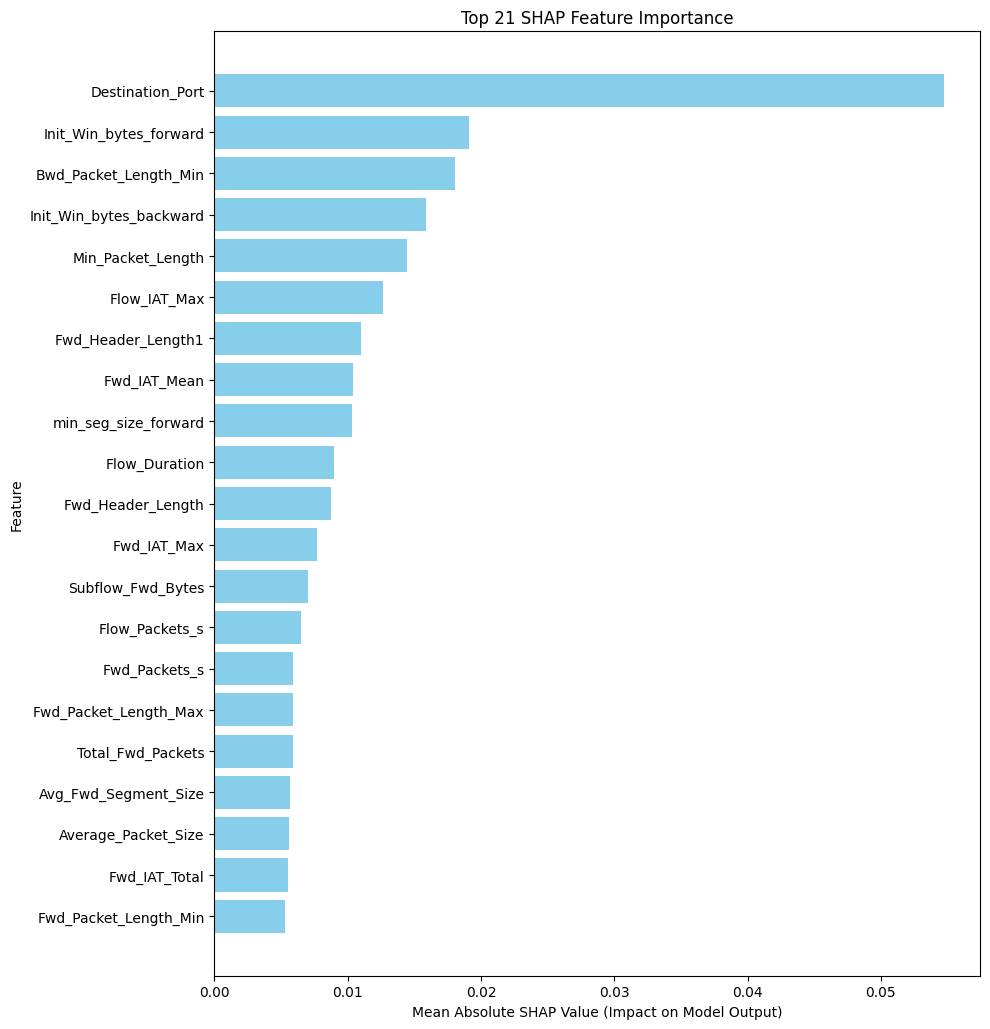

✅ Explicit SHAP Bar Plot generation code executed.


In [8]:
# --- NEW: SHAP Explanations for Selected Features (Interpretability) ---
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.ensemble import RandomForestClassifier
import shap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("\n--- Generating SHAP Explanations for Selected Features ---")
# This RF acts as a proxy model for interpretability, not the final IDS Stage 1 model.

# --- IMPORTANT ---
# Ensure the variables X_train_fs and y_bin_train_fs from your data reduction step
# are used here. The KeyError could also originate from using incorrect keys
# in a dictionary like 'data_for_modeling'.
# This code assumes X_train_fs and y_bin_train_fs are in your current scope.

X_train_for_shap = X_train_fs
y_bin_train_for_shap = y_bin_train_fs # Use binary labels for simplicity with SHAP

# --- SHAP Subsampling for large datasets ---
# Calculate SHAP values on a subsample if the training data is very large.
SHAP_EXPLANATION_SAMPLE_SIZE = 50000 # Adjust based on RAM/runtime.

if X_train_for_shap.shape[0] > SHAP_EXPLANATION_SAMPLE_SIZE:
    print(f"    Subsampling {SHAP_EXPLANATION_SAMPLE_SIZE} rows from {X_train_for_shap.shape[0]} for SHAP value calculation.")

    # Stratified subsampling for SHAP explanation dataset
    # Using a fixed SEED for reproducibility
    SEED = 42
    shap_splitter = StratifiedShuffleSplit(n_splits=1, train_size=SHAP_EXPLANATION_SAMPLE_SIZE, random_state=SEED)

    for shap_train_idx, _ in shap_splitter.split(X_train_for_shap, y_bin_train_for_shap):
        X_shap_sample = X_train_for_shap.iloc[shap_train_idx].copy()
        
        # Use .iloc for positional indexing because the original index
        # was shuffled by previous sampling steps.
        y_shap_sample = y_bin_train_for_shap.iloc[shap_train_idx].copy()
else:
    print("    Using full training data for SHAP value calculation.")
    X_shap_sample = X_train_for_shap.copy()
    y_shap_sample = y_bin_train_for_shap.copy()


# Train a simple RandomForestClassifier for SHAP explanation
shap_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED, n_jobs=-1)
print(f"    Training a proxy Random Forest model (n_estimators={shap_model.n_estimators}, max_depth={shap_model.max_depth}) for SHAP explanation...")
shap_model.fit(X_shap_sample, y_shap_sample)
print("    Proxy model trained.")

# Create a SHAP explainer
explainer = shap.TreeExplainer(shap_model)

print(f"    Calculating SHAP values for {X_shap_sample.shape[0]} samples (this may take a moment)...")
shap_values = explainer.shap_values(X_shap_sample)

# For binary classification, we are interested in the positive class (ATTACK), which is index 1.
if isinstance(shap_values, list): # Check for multi-class output
    shap_values_to_plot = shap_values[1] # For the 'ATTACK' class (label 1)
else: # For binary classification models, it might directly return one array
    shap_values_to_plot = shap_values

print("\n--- Data Preparation with Dynamic Feature Selection Complete ---")

# --- Explicit SHAP Bar Plot Code Snippet ---
print("\nGenerating SHAP Bar Plot (Mean Absolute Importance)...")

# --- 🐛 VALUEERROR FIX IS HERE 🐛 ---
# The traceback indicates `mean_abs_shap_values` became a 2D array, which `pd.Series` rejects.
# This happens if `shap_values_to_plot` is 3D (e.g., shape [samples, features, 2]).
# We add a check to handle this by collapsing the last dimension, ensuring the result is 1D.

# Check if the shap values array is 3D. If so, sum across the last dimension.
if shap_values_to_plot.ndim == 3:
    print("    Detected 3D SHAP values array. Summing across the last dimension to flatten.")
    shap_values_2d = np.abs(shap_values_to_plot).sum(axis=2)
else:
    shap_values_2d = np.abs(shap_values_to_plot)

# Now, calculate the mean absolute SHAP value for each feature across all samples.
# This will correctly result in a 1D array.
mean_abs_shap_values = shap_values_2d.mean(axis=0)

# Create a Pandas Series for easy sorting and plotting
shap_importance = pd.Series(mean_abs_shap_values, index=X_shap_sample.columns)

# Sort features by importance for the horizontal bar plot
shap_importance_sorted = shap_importance.sort_values(ascending=True)

# --- EDIT: Select only the top 21 features for plotting ---
N_TOP_FEATURES = 21
if len(shap_importance_sorted) > N_TOP_FEATURES:
    print(f"    Displaying top {N_TOP_FEATURES} features in the SHAP plot.")
    shap_importance_top_n = shap_importance_sorted.tail(N_TOP_FEATURES)
else:
    print(f"    Displaying all {len(shap_importance_sorted)} features as there are fewer than {N_TOP_FEATURES}.")
    shap_importance_top_n = shap_importance_sorted


# Plotting
plt.figure(figsize=(10, len(shap_importance_top_n) * 0.4 + 2)) # Dynamic figure size based on num features
plt.barh(shap_importance_top_n.index, shap_importance_top_n.values, color='skyblue')
plt.xlabel("Mean Absolute SHAP Value (Impact on Model Output)")
plt.ylabel("Feature")
plt.title(f"Top {len(shap_importance_top_n)} SHAP Feature Importance")
plt.tight_layout()
plt.show()

print("✅ Explicit SHAP Bar Plot generation code executed.")



In [9]:
# --- Q1-READY CODE BLOCK 3: Stage 1 - Random Forest Binary Classification ---

import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (classification_report, accuracy_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
# Assume previous setup has been done:
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler
# SEED = 42
# CLASS_NAMES_BINARY = ['BENIGN', 'ATTACK']
# def plot_confusion_matrix(y_true, y_pred, class_names, title): ...

print("\n--- Starting Stage 1: Random Forest Binary Classification ---")

# Retrieve the prepared data from the previous block (data_for_modeling dictionary)
# Note: Ensure this dictionary is available from the preceding code block.
X_train_scaled = data_for_modeling['X_train_scaled']
X_test_scaled = data_for_modeling['X_test_scaled']
y_bin_train = data_for_modeling['y_bin_train']
y_bin_test = data_for_modeling['y_bin_test']

# --- ✅ NEW MEMORY OPTIMIZATION STEP ---
print("\nApplying on-the-spot memory optimization...")
# Downcast the numpy arrays from float64 to float32 to save 50% of their memory
X_train_scaled = X_train_scaled.astype('float32')
X_test_scaled = X_test_scaled.astype('float32')
print(f"New data type for feature arrays: {X_train_scaled.dtypes}")


# 1. Random Forest for Supervised Classification
print("\n1. Training Random Forest for Supervised Classification...")

# Hyperparameter Tuning for Random Forest (Q1 Requirement)
# We will use RandomizedSearchCV to find the best model parameters.
# Define a reasonable parameter grid. For production, this grid can be expanded.
param_dist_rf = {
    'n_estimators': [100, 200],      # Number of trees in the forest
    'max_depth': [10, 30],      # Maximum depth of the tree
    'min_samples_split': [5, 10],      # Minimum samples required to split a node
    'class_weight': ['balanced']      # Use 'balanced' to handle potential class imbalance
}

print("    Starting RandomizedSearchCV for Random Forest (may take a while)...")
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=SEED), # Estimator doesn't need n_jobs
    param_distributions=param_dist_rf,
    n_iter=4,                     # Reduced from 8 to a smaller number of iterations
    cv=3,                         # Use 3-fold cross-validation
    scoring='f1',                 # Optimize for F1-score
    n_jobs=2,                     # **Reduced from -1 to 2 to limit parallel jobs and save memory**
    random_state=SEED,            # For reproducible results
    verbose=1
)


# Train the model using the scaled training data
rf_random_search.fit(X_train_scaled, y_bin_train)

# The best model found by RandomSearchCV
best_rf_bin = rf_random_search.best_estimator_

print(f"\n✅ Best Random Forest parameters found: {rf_random_search.best_params_}")
print(f"✅ Best Random Forest F1-score from Cross-Validation: {rf_random_search.best_score_:.4f}")
print("✅ Random Forest classifier trained with optimized hyperparameters.")


# 2. Evaluation of the Stage 1 Random Forest Model
print("\n--- Evaluation of Stage 1: Random Forest Binary Classification ---")

# Generate predictions on the test set using the best model
y_bin_pred_rf = best_rf_bin.predict(X_test_scaled)

# Generate and print the classification report
report_rf = classification_report(y_bin_test, y_bin_pred_rf, target_names=CLASS_NAMES_BINARY, output_dict=True)
print(classification_report(y_bin_test, y_bin_pred_rf, target_names=CLASS_NAMES_BINARY))

# Calculate and display key performance metrics
acc_rf = accuracy_score(y_bin_test, y_bin_pred_rf)
prec_rf = precision_score(y_bin_test, y_bin_pred_rf, pos_label=1)
rec_rf = recall_score(y_bin_test, y_bin_pred_rf, pos_label=1)
f1_rf = f1_score(y_bin_test, y_bin_pred_rf, pos_label=1)
conf_mat_rf = confusion_matrix(y_bin_test, y_bin_pred_rf, labels=[0, 1])

print(f"    Accuracy         : {acc_rf:.4f}")
print(f"    Precision        : {prec_rf:.4f}")
print(f"    Recall           : {rec_rf:.4f}")
print(f"    F1 Score         : {f1_rf:.4f}")
print("    Confusion Matrix:")
print(conf_mat_rf)

# Plot the confusion matrix for the Random Forest model
# Assumes plot_confusion_matrix function is defined elsewhere
# plot_confusion_matrix(y_bin_test, y_bin_pred_rf, class_names=CLASS_NAMES_BINARY, title="Confusion Matrix: Stage 1 (Random Forest)")


# 3. Store the outputs needed for Stage 2
print("\n3. Packaging artifacts for the next stage...")

# Retrieve multiclass labels needed for Stage 2
y_multi_train = data_for_modeling['y_multi_train']
y_multi_test = data_for_modeling['y_multi_test']

# This dictionary contains all the necessary data and models for the next stage
stage1_outputs = {
    'X_train_final': X_train_scaled,         # Scaled training features
    'X_test_final': X_test_scaled,           # Scaled testing features
    'y_multi_train': y_multi_train,          # Multiclass labels for training Stage 2
    'y_multi_test': y_multi_test,            # Multiclass labels for testing Stage 2
    'y_bin_train': y_bin_train,              # <-- THE MISSING BINARY LABELS FOR TRAINING
    'rf_bin_model': best_rf_bin,             # The trained binary Random Forest model
    'stage1_rf_predictions_test': y_bin_pred_rf, # Final binary predictions for the test set
    'stage1_metrics': report_rf              # The detailed classification report
}

print("✅ All necessary data, models, and predictions have been stored.")
print("\n--- Stage 1: Binary Classification Complete ---")


--- Starting Stage 1: Random Forest Binary Classification ---

Applying on-the-spot memory optimization...
New data type for feature arrays: Min_Packet_Length          float32
Flow_IAT_Min               float32
URG_Flag_Count             float32
Destination_Port           float32
Bwd_Packet_Length_Min      float32
Idle_Std                   float32
Down_Up_Ratio              float32
Fwd_Packets_s              float32
Init_Win_bytes_backward    float32
FIN_Flag_Count             float32
Flow_Packets_s             float32
Active_Std                 float32
Bwd_Packets_s              float32
SYN_Flag_Count             float32
Fwd_PSH_Flags              float32
Bwd_IAT_Std                float32
Active_Min                 float32
ACK_Flag_Count             float32
Fwd_Packet_Length_Std      float32
Flow_IAT_Mean              float32
PSH_Flag_Count             float32
dtype: object

1. Training Random Forest for Supervised Classification...
    Starting RandomizedSearchCV for Random Forest

In [10]:
# --- Diagnostic Print Block ---
# Add this code in a new cell right after defining stage1_outputs
# to verify the shapes of the data being passed to Stage 2.

print("\n--- Verifying Shapes in 'stage1_outputs' Dictionary ---")
for key, value in stage1_outputs.items():
    if hasattr(value, 'shape'):
        print(f"Shape of '{key}': {value.shape}")
    else:
        print(f"'{key}' is not an array/dataframe, it's a {type(value)}")


--- Verifying Shapes in 'stage1_outputs' Dictionary ---
Shape of 'X_train_final': (4296150, 21)
Shape of 'X_test_final': (847965, 21)
Shape of 'y_multi_train': (4296150,)
Shape of 'y_multi_test': (847965,)
Shape of 'y_bin_train': (4296150,)
'rf_bin_model' is not an array/dataframe, it's a <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Shape of 'stage1_rf_predictions_test': (847965,)
'stage1_metrics' is not an array/dataframe, it's a <class 'dict'>


In [11]:
# Apne notebook ke sabse pehle cell mein is code ko run karein
import torch

# Find the installed PyTorch version
TORCH_VERSION = torch.__version__
print(f"PyTorch version: {TORCH_VERSION}")

# Install the required helper libraries compatible with your PyTorch version
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-{TORCH_VERSION}.html

print("\n✅ Helper libraries installed successfully!")

PyTorch version: 2.6.0+cu124
Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html

✅ Helper libraries installed successfully!


--- Assuming 'stage1_outputs' and 'y_bin_train' are pre-loaded in the environment ---

--- Starting Stage 2: Multi-Class Attack Classification (GNN + Bayesian Layer) ---
✅ Multiclass attack labels re-encoded from 0 to 7.
     Distribution of re-encoded training attack labels: Counter({0: 477350, 1: 477350, 2: 477350, 3: 477350, 4: 477350, 5: 477350, 6: 477350, 7: 477350})

--- Splitting data into Training and Validation sets (80/20) ---
     New Training Set Shape: (3055040, 21)
     New Validation Set Shape: (763760, 21)
     Unseen Test Set Shape: (165630, 21)

Using device: cuda

--- Preparing Training Data Loader ---
     Building k-NN graph on GPU in batches for 3055040 nodes...
✅ NeighborLoader for training created.

--- Preparing Validation Data Loader ---
     Building k-NN graph on GPU in batches for 763760 nodes...
✅ NeighborLoader for validation created.

--- Training Stage 2: GNN Bayesian Model with Mini-Batching ---

🚀 Starting training for Learning Rate (LR): 0.15
CUDA ca

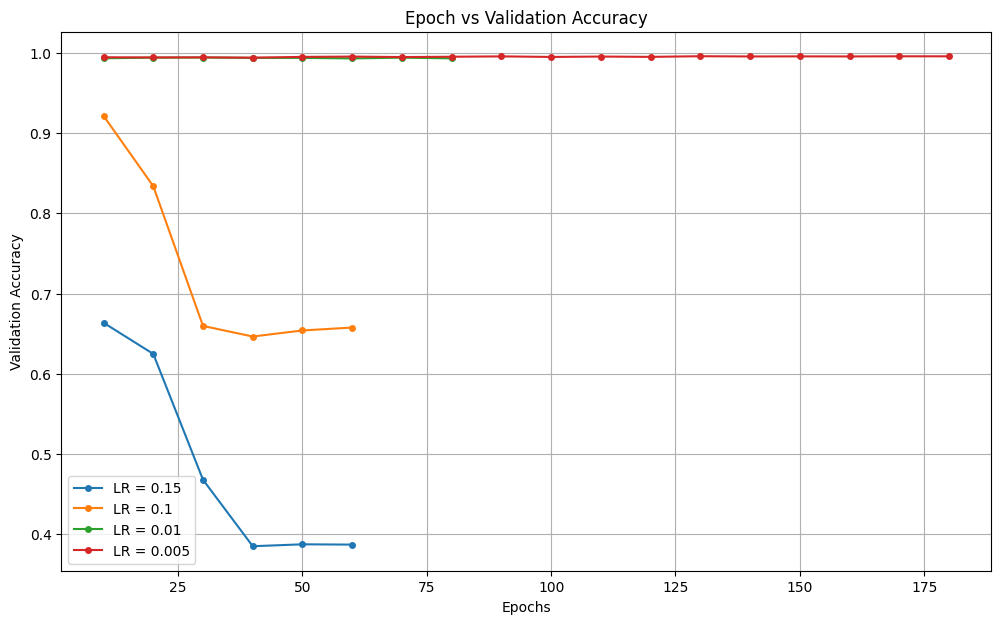

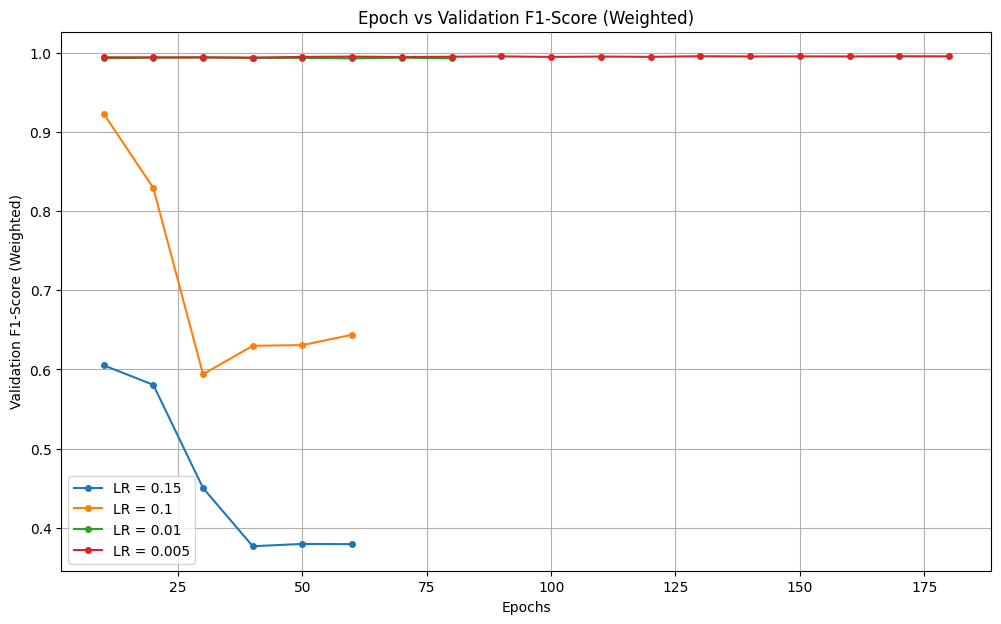


--- Final Evaluation of Stage 2: GNN Bayesian Model on UNSEEN Test Set ---
Loading best model found during validation (trained with LR=0.005)
     Building test graph safely on GPU using batched method...
     Building k-NN graph on GPU in batches for 165630 nodes...

=== Stage 2: Final Classification Report on UNSEEN Test Set ===
              precision    recall  f1-score   support

           1       1.00      1.00      1.00     38422
           2       0.98      1.00      0.99      3043
           3       1.00      1.00      1.00     69068
           4       0.97      0.99      0.98      1636
           5       0.98      0.98      0.98      1782
           6       1.00      1.00      1.00      2345
           7       1.00      1.00      1.00     47546
           8       0.99      0.99      0.99      1788

    accuracy                           1.00    165630
   macro avg       0.99      0.99      0.99    165630
weighted avg       1.00      1.00      1.00    165630



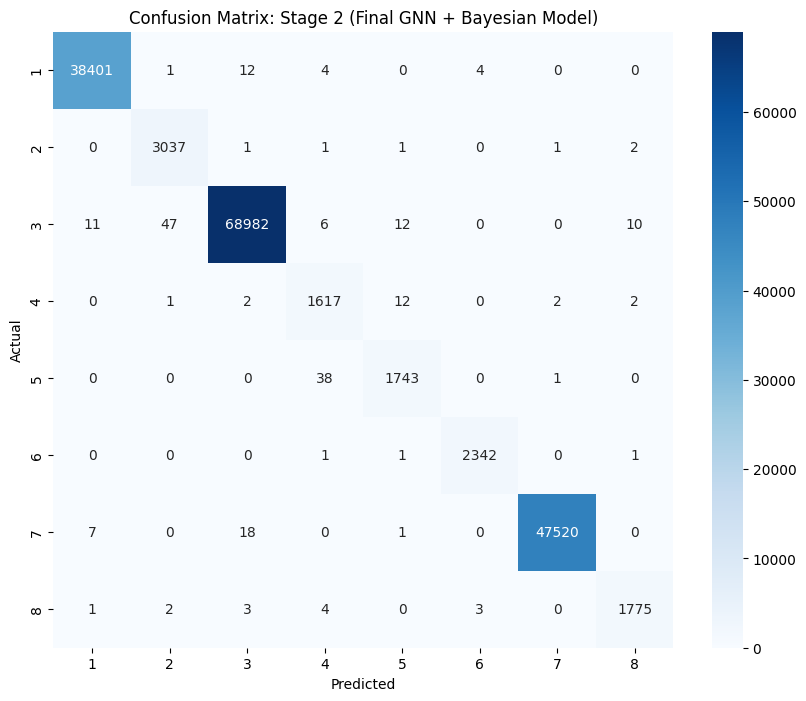

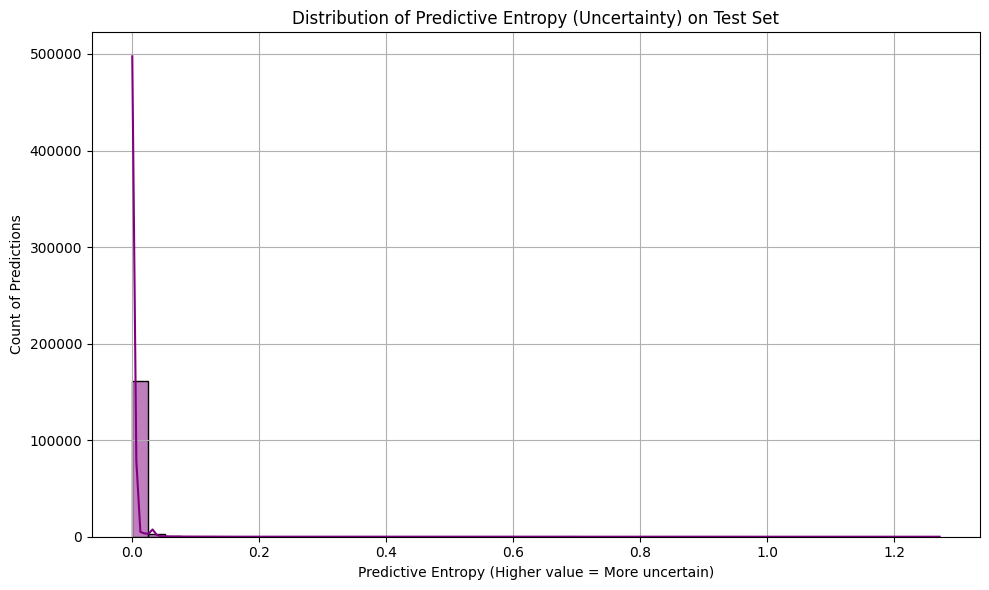


--- Stage 2: Multi-Class Classification Complete ---


In [12]:
# --- Combined & Optimized Code: Stage 2 - GNN + Bayesian Layer ---
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Normal
import torch_geometric.nn as pyg_nn
from torch_geometric.data import Data # <-- IMPORTED FOR PyG DATA OBJECTS
from torch_geometric.loader import NeighborLoader # <-- IMPORTED FOR MINI-BATCHING
from torch_geometric.utils import from_scipy_sparse_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, f1_score, confusion_matrix
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import cupy as cp
import cudf
from cuml.neighbors import NearestNeighbors as cuNearestNeighbors

# --- HELPER FUNCTION (Unchanged) ---
def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    """Plots a confusion matrix using seaborn."""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

# --- DATA LOADING (Unchanged) ---
print("--- Assuming 'stage1_outputs' and 'y_bin_train' are pre-loaded in the environment ---")
if 'stage1_outputs' not in locals() or 'y_bin_train' not in locals():
    raise NameError("The required variables were not found. Please run the full pipeline from the top.")

print("\n--- Starting Stage 2: Multi-Class Attack Classification (GNN + Bayesian Layer) ---")

# =====================================================================================
# 1. Data Preparation (Unchanged)
# =====================================================================================
# Unpack data
X_train_full_features = stage1_outputs['X_train_final']
X_test_full_features = stage1_outputs['X_test_final']
y_multi_train_full = stage1_outputs['y_multi_train']
y_multi_test_full = stage1_outputs['y_multi_test']
y_bin_train = stage1_outputs['y_bin_train']
stage1_test_hybrid_preds = stage1_outputs['stage1_rf_predictions_test']

# Reset indices
X_train_full_features.reset_index(drop=True, inplace=True)
y_multi_train_full.reset_index(drop=True, inplace=True)
y_bin_train.reset_index(drop=True, inplace=True)
X_test_full_features.reset_index(drop=True, inplace=True)
y_multi_test_full.reset_index(drop=True, inplace=True)

# Filter for attack samples
initial_benign_label_multi = 0
train_mask = (y_bin_train == 1) & (y_multi_train_full != initial_benign_label_multi)
X_attack_train_full_df = X_train_full_features[train_mask].copy()
y_attack_train_full_multi_df = y_multi_train_full[train_mask].copy()
test_mask = (stage1_test_hybrid_preds == 1) & (y_multi_test_full != initial_benign_label_multi)
X_attack_test_df = X_test_full_features[test_mask].copy()
y_attack_test_multi_df = y_multi_test_full[test_mask].copy()

# Re-encode labels
le_attack_classes = LabelEncoder()
y_attack_train_full_encoded_np = le_attack_classes.fit_transform(y_attack_train_full_multi_df)
y_attack_test_encoded_np = le_attack_classes.transform(y_attack_test_multi_df)
NUM_ATTACK_CLASSES = len(le_attack_classes.classes_)
ATTACK_CLASS_NAMES = le_attack_classes.classes_
print(f"✅ Multiclass attack labels re-encoded from 0 to {NUM_ATTACK_CLASSES - 1}.")
print(f"     Distribution of re-encoded training attack labels: {Counter(y_attack_train_full_encoded_np)}")

# Train/Val Split
print("\n--- Splitting data into Training and Validation sets (80/20) ---")
X_train_df, X_val_df, y_train_np, y_val_np = train_test_split(
    X_attack_train_full_df, y_attack_train_full_encoded_np,
    test_size=0.2, random_state=42, stratify=y_attack_train_full_encoded_np
)
print(f"     New Training Set Shape: {X_train_df.shape}")
print(f"     New Validation Set Shape: {X_val_df.shape}")
print(f"     Unseen Test Set Shape: {X_attack_test_df.shape}")

# =====================================================================================
# 2. FINAL & FASTEST: Batched GPU Graph Construction & Data Loaders
# =====================================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\nUsing device: {device}")

# --- NEW Helper Function: Builds graph in batches on GPU to prevent OOM ---
def build_gpu_graph_in_batches(df, batch_size=200000, k_neighbors=5):
    """
    Builds a k-NN graph using cuML in batches to avoid GPU OOM errors.
    This is much faster than using the CPU.
    """
    print(f"     Building k-NN graph on GPU in batches for {df.shape[0]} nodes...")
    
    # Fit Nearest Neighbors on the entire dataset (this part is memory-efficient)
    full_cudf = cudf.DataFrame(df.values)
    nbrs = cuNearestNeighbors(n_neighbors=k_neighbors, metric='cosine')
    nbrs.fit(full_cudf)
    
    all_rows, all_cols = [], []
    
    # Process in batches to find neighbors (this is the memory-intensive part)
    for i in range(0, df.shape[0], batch_size):
        start, end = i, min(i + batch_size, df.shape[0])
        # print(f"          Processing batch: {start} to {end}")
        
        batch_cudf = full_cudf.iloc[start:end]
        _, indices = nbrs.kneighbors(batch_cudf)
        
        # Create row indices for this batch
        rows = cp.repeat(cp.arange(start, end), k_neighbors)
        cols = indices.values.flatten()
        
        all_rows.append(rows)
        all_cols.append(cols)
        
    # Concatenate all batch results on GPU
    final_rows = cp.concatenate(all_rows)
    final_cols = cp.concatenate(all_cols)
    data = cp.ones(final_rows.shape[0], dtype=cp.float32)

    # Create the final sparse matrix and convert to edge_index
    adj_matrix_sparse = cp.sparse.coo_matrix(
        (data, (final_rows, final_cols)),
        shape=(df.shape[0], df.shape[0])
    )
    edge_index, _ = from_scipy_sparse_matrix(adj_matrix_sparse.get())
    return edge_index

# 1. Create Training Data Loader (using FAST, batched GPU graph construction)
print("\n--- Preparing Training Data Loader ---")
train_edge_index = build_gpu_graph_in_batches(X_train_df)
train_data = Data(
    x=torch.FloatTensor(X_train_df.values),
    edge_index=train_edge_index,
    y=torch.LongTensor(y_train_np)
)
train_loader = NeighborLoader(
    train_data,
    num_neighbors=[15, 10],
    batch_size=1024, # Adjust this based on your GPU memory (e.g., 512, 2048)
    shuffle=True,
    num_workers=2
)
print("✅ NeighborLoader for training created.")

# 2. Create Validation Data Loader (also using FAST, batched GPU graph construction)
print("\n--- Preparing Validation Data Loader ---")
val_edge_index = build_gpu_graph_in_batches(X_val_df)
val_data = Data(
    x=torch.FloatTensor(X_val_df.values),
    edge_index=val_edge_index,
    y=torch.LongTensor(y_val_np)
)
val_loader = NeighborLoader(
    val_data,
    num_neighbors=[-1], # -1 means use all neighbors for accurate validation. Can be memory intensive.
    batch_size=2048,    # If validation causes OOM, reduce this batch_size.
    shuffle=False
)
print("✅ NeighborLoader for validation created.")

# Test data tensors are prepared but the graph will be built during final evaluation
X_test_tensor_stage2 = torch.FloatTensor(X_attack_test_df.values).to(device)
y_test_tensor_stage2 = torch.LongTensor(y_attack_test_encoded_np).to(device)


# =====================================================================================
# 3. Model Definition (Unchanged)
# =====================================================================================
class BayesianLayer(nn.Module):
    def __init__(self, in_features, out_features, prior_sigma=1.0):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.prior_sigma = prior_sigma
        self.mu_w = nn.Parameter(torch.Tensor(out_features, in_features))
        self.rho_w = nn.Parameter(torch.Tensor(out_features, in_features))
        self.epsilon = Normal(0, 1)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.mu_w)
        nn.init.constant_(self.rho_w, -5)

    def forward(self, x):
        sigma_w = torch.log1p(torch.exp(self.rho_w))
        eps_w = self.epsilon.sample(self.mu_w.size()).to(x.device)
        weight = self.mu_w + sigma_w * eps_w
        kl_divergence = 0.5 * torch.sum(
            2 * torch.log(self.prior_sigma / sigma_w) - 1 + (sigma_w**2 + self.mu_w**2) / (self.prior_sigma**2)
        )
        return F.linear(x, weight), kl_divergence

class GNNBayesianIDS(nn.Module):
    def __init__(self, in_features, hidden_size, num_classes, dropout_rate=0.5):
        super().__init__()
        self.conv1 = pyg_nn.GCNConv(in_features, hidden_size)
        self.bayesian_output = BayesianLayer(hidden_size, num_classes)
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x_features, edge_index, is_training=True):
        x = self.conv1(x_features, edge_index)
        x = F.relu(x)
        if is_training:
            x = self.dropout(x)
        logits, kl_loss = self.bayesian_output(x)
        return F.log_softmax(logits, dim=1), kl_loss

# =====================================================================================
# 4. NEW: Training & Hyperparameter Tuning Loop with Mini-Batching
# =====================================================================================
print("\n--- Training Stage 2: GNN Bayesian Model with Mini-Batching ---")
LEARNING_RATES_FOR_PLOT = [0.15, 0.1, 0.01, 0.005]
EPOCHS_MAX = 700 # NOTE: Mini-batching might require more epochs to converge fully
PATIENCE_EARLY_STOPPING = 50

all_lr_results = {}
best_model_state = None
best_overall_val_f1 = -1
best_lr = None

for lr in LEARNING_RATES_FOR_PLOT:
    print(f"\n🚀 Starting training for Learning Rate (LR): {lr}")
    model = GNNBayesianIDS(
        in_features=X_train_df.shape[1],
        hidden_size=128,
        num_classes=NUM_ATTACK_CLASSES,
        dropout_rate=0.5
    ).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.NLLLoss(reduction='sum')
    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': [], 'epochs': []}
    best_val_loss = float('inf')
    epochs_no_improve = 0

    for epoch in range(EPOCHS_MAX):
        model.train()
        total_epoch_loss = 0
        
        # --- Training Loop with Mini-Batches ---
        for batch in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            log_probs, kl_loss = model(batch.x, batch.edge_index, is_training=True)
            nll_loss = criterion(log_probs[:batch.batch_size], batch.y[:batch.batch_size])
            total_loss = nll_loss + (kl_loss / batch.batch_size)
            total_loss.backward()
            optimizer.step()
            total_epoch_loss += total_loss.item()
        avg_epoch_loss = total_epoch_loss / len(train_loader)

        # --- Validation Loop (every 10 epochs) ---
        if (epoch + 1) % 10 == 0 or epoch == EPOCHS_MAX - 1:
            model.eval()
            with torch.no_grad():
                total_val_loss = 0
                all_preds, all_true = [], []
                for batch in val_loader:
                    batch = batch.to(device)
                    log_probs_val, _ = model(batch.x, batch.edge_index, is_training=False)
                    val_loss = criterion(log_probs_val[:batch.batch_size], batch.y[:batch.batch_size])
                    total_val_loss += val_loss.item()
                    preds = torch.argmax(log_probs_val[:batch.batch_size], dim=1)
                    all_preds.append(preds.cpu())
                    all_true.append(batch.y[:batch.batch_size].cpu())

                y_pred_val = torch.cat(all_preds).numpy()
                y_true_val = torch.cat(all_true).numpy()
                val_acc = accuracy_score(y_true_val, y_pred_val)
                val_f1 = f1_score(y_true_val, y_pred_val, average='weighted', zero_division=0)
                avg_val_loss = total_val_loss / len(val_loader)
                
                history.update({
                    'train_loss': history.get('train_loss', []) + [avg_epoch_loss],
                    'val_loss': history.get('val_loss', []) + [avg_val_loss],
                    'val_acc': history.get('val_acc', []) + [val_acc],
                    'val_f1': history.get('val_f1', []) + [val_f1],
                    'epochs': history.get('epochs', []) + [epoch + 1]
                })
                
                print(f"     Epoch {epoch+1}/{EPOCHS_MAX} | Train Loss: {avg_epoch_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")

                # Early stopping and best model saving logic
                if avg_val_loss < best_val_loss:
                    best_val_loss = avg_val_loss
                    epochs_no_improve = 0
                    if val_f1 > best_overall_val_f1:
                        best_overall_val_f1 = val_f1
                        best_lr = lr
                        best_model_state = model.state_dict()
                        print(f"     🌟 New best model found! Val F1: {val_f1:.4f} with LR: {lr}")
                else:
                    epochs_no_improve += 1
                    if epochs_no_improve >= (PATIENCE_EARLY_STOPPING // 10):
                        print(f"     Early stopping for LR={lr} at Epoch {epoch+1}")
                        break
    all_lr_results[lr] = history

# =====================================================================================
# 5. Plotting Hyperparameter Tuning Results (Unchanged)
# =====================================================================================
print("\n--- Plotting Epoch vs Validation Metrics for Different Learning Rates ---")
plt.figure(figsize=(12, 7))
for lr, history in all_lr_results.items():
    plt.plot(history['epochs'], history['val_acc'], label=f"LR = {lr}", marker='o', markersize=4)
plt.title("Epoch vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 7))
for lr, history in all_lr_results.items():
    plt.plot(history['epochs'], history['val_f1'], label=f"LR = {lr}", marker='o', markersize=4)
plt.title("Epoch vs Validation F1-Score (Weighted)")
plt.xlabel("Epochs")
plt.ylabel("Validation F1-Score (Weighted)")
plt.legend()
plt.grid(True)
plt.show()

# =====================================================================================
# 6. Final Evaluation on UNSEEN Test Set (Updated for safe graph construction)
# =====================================================================================
print("\n--- Final Evaluation of Stage 2: GNN Bayesian Model on UNSEEN Test Set ---")
if best_model_state is None:
    print("⚠️ No best model was saved. Evaluation cannot proceed.")
else:
    print(f"Loading best model found during validation (trained with LR={best_lr})")
    final_model = GNNBayesianIDS(
        in_features=X_train_df.shape[1], hidden_size=128, num_classes=NUM_ATTACK_CLASSES
    ).to(device)
    final_model.load_state_dict(best_model_state)
    final_model.eval()

    with torch.no_grad():
        print("     Building test graph safely on GPU using batched method...")
        test_edge_index = build_gpu_graph_in_batches(X_attack_test_df)
        test_edge_index = test_edge_index.to(device)
        
        NUM_MC_SAMPLES_FINAL = 50
        final_mc_log_probs = []
        for _ in range(NUM_MC_SAMPLES_FINAL):
            log_probs_test_sample, _ = final_model(X_test_tensor_stage2, test_edge_index, is_training=False)
            final_mc_log_probs.append(log_probs_test_sample.unsqueeze(0))

        final_mc_log_probs_tensor = torch.cat(final_mc_log_probs, dim=0)
        final_mean_log_probs = torch.logsumexp(final_mc_log_probs_tensor, dim=0) - torch.log(torch.tensor(NUM_MC_SAMPLES_FINAL, dtype=torch.float)).to(device)
        final_y_pred_encoded = torch.argmax(final_mean_log_probs, dim=1).cpu().numpy()
        
        final_mean_probs = torch.exp(final_mean_log_probs)
        final_predictive_entropy = -torch.sum(final_mean_probs * torch.log(final_mean_probs + 1e-10), dim=1).cpu().numpy()

    # =====================================================================================
    # 7. Final Reporting and Visualization (Unchanged)
    # =====================================================================================
    print("\n=== Stage 2: Final Classification Report on UNSEEN Test Set ===")
    print(classification_report(y_test_tensor_stage2.cpu().numpy(), final_y_pred_encoded, target_names=[str(cls) for cls in ATTACK_CLASS_NAMES], zero_division=0))
    plot_confusion_matrix(y_test_tensor_stage2.cpu().numpy(), final_y_pred_encoded, class_names=[str(cls) for cls in ATTACK_CLASS_NAMES], title="Confusion Matrix: Stage 2 (Final GNN + Bayesian Model)")

    plt.figure(figsize=(10, 6))
    sns.histplot(final_predictive_entropy, bins=50, kde=True, color='purple')
    plt.title("Distribution of Predictive Entropy (Uncertainty) on Test Set")
    plt.xlabel("Predictive Entropy (Higher value = More uncertain)")
    plt.ylabel("Count of Predictions")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

print("\n--- Stage 2: Multi-Class Classification Complete ---")




--- Final Consolidated Results and System Evaluation ---

=== Stage 1: Binary Classification (Final Metrics) ===
Accuracy: 0.9979
Precision (ATTACK): 0.9915
Recall (ATTACK): 0.9976
F1-Score (ATTACK): 0.9945
Confusion Matrix (ATTACK vs. BENIGN):
[[680516   1413]
 [   406 165630]]

=== Stage 2: GNN Bayesian Multi-Class Classification (Final Metrics) ===
Best Learning Rate Used: 0.005 (determined during validation)
Accuracy: 0.9987
Weighted Precision: 0.9987
Weighted Recall: 0.9987
Weighted F1-Score: 0.9987

--- Detailed Per-Class Metrics for Stage 2 ---
  Class 'DDoS': Precision=0.9995, Recall=0.9995, F1-score=0.9995
  Class 'DoS GoldenEye': Precision=0.9835, Recall=0.9980, F1-score=0.9907
  Class 'DoS Hulk': Precision=0.9995, Recall=0.9988, F1-score=0.9991
  Class 'DoS Slowhttptest': Precision=0.9677, Recall=0.9884, F1-score=0.9779
  Class 'DoS slowloris': Precision=0.9847, Recall=0.9781, F1-score=0.9814
  Class 'FTP-Patator': Precision=0.9970, Recall=0.9987, F1-score=0.9979
  Class 'P

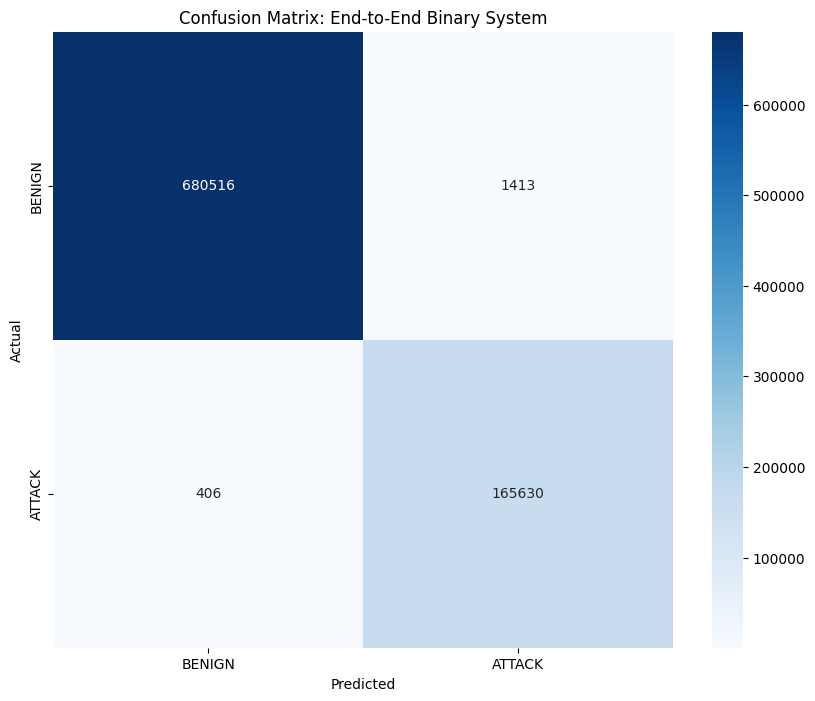


--- End-to-End Multi-Class Performance ---
                  precision    recall  f1-score   support

          BENIGN       1.00      1.00      1.00    681929
            DDoS       1.00      1.00      1.00     38431
   DoS GoldenEye       0.98      0.99      0.99      3057
        DoS Hulk       1.00      0.99      1.00     69378
DoS Slowhttptest       0.97      0.99      0.98      1640
   DoS slowloris       0.98      0.98      0.98      1786
     FTP-Patator       1.00      1.00      1.00      2346
        PortScan       1.00      1.00      1.00     47609
     SSH-Patator       0.99      0.99      0.99      1789

        accuracy                           1.00    847965
       macro avg       0.99      0.99      0.99    847965
    weighted avg       1.00      1.00      1.00    847965



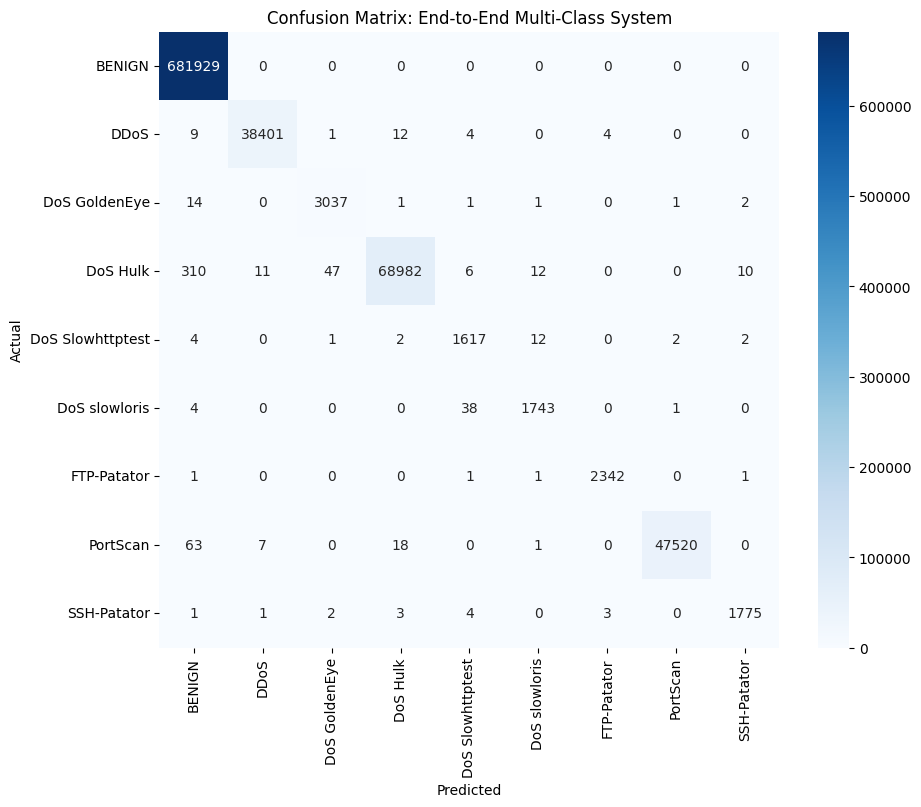


--- All Pipeline Stages Completed and Evaluated ---


In [13]:
# --- Q1-READY CODE BLOCK 5: Consolidated Results, Final Reporting, and System-Level Metrics (Corrected) ---

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

print("\n--- Final Consolidated Results and System Evaluation ---")

# =====================================================================================
# 1. Retrieve Necessary Data and Outputs
# =====================================================================================
# These variables should be available from the previous blocks' execution
y_bin_test = data_for_modeling['y_bin_test']
y_multi_test_full_original = data_for_modeling['y_multi_test']


# =====================================================================================
# 2. Report Stage 1 Performance
# =====================================================================================
print("\n=== Stage 1: Binary Classification (Final Metrics) ===")
# The classification_report function returns a dictionary when output_dict=True
stage1_report_dict = classification_report(y_bin_test, stage1_outputs['stage1_rf_predictions_test'], target_names=CLASS_NAMES_BINARY, output_dict=True)
print(f"Accuracy: {stage1_report_dict['accuracy']:.4f}")
print(f"Precision (ATTACK): {stage1_report_dict['ATTACK']['precision']:.4f}")
print(f"Recall (ATTACK): {stage1_report_dict['ATTACK']['recall']:.4f}")
print(f"F1-Score (ATTACK): {stage1_report_dict['ATTACK']['f1-score']:.4f}")
print("Confusion Matrix (ATTACK vs. BENIGN):")
print(confusion_matrix(y_bin_test, stage1_outputs['stage1_rf_predictions_test']))


# =====================================================================================
# 3. Report Stage 2 Standalone Performance
# =====================================================================================
report_stage2_final = classification_report(
    y_test_tensor_stage2.cpu().numpy(),
    final_y_pred_encoded,
    target_names=[str(cls) for cls in le_attack_classes.classes_], # Use le_attack_classes here
    zero_division=0,
    output_dict=True
)

print("\n=== Stage 2: GNN Bayesian Multi-Class Classification (Final Metrics) ===")
print(f"Best Learning Rate Used: {best_lr} (determined during validation)")
print(f"Accuracy: {report_stage2_final['accuracy']:.4f}")
print(f"Weighted Precision: {report_stage2_final['weighted avg']['precision']:.4f}")
print(f"Weighted Recall: {report_stage2_final['weighted avg']['recall']:.4f}")
print(f"Weighted F1-Score: {report_stage2_final['weighted avg']['f1-score']:.4f}")

print("\n--- Detailed Per-Class Metrics for Stage 2 ---")
# Get the original string names for the attack classes for clearer reporting
attack_class_string_names = LABEL_ENCODER_MULTI.inverse_transform(le_attack_classes.classes_)
for i, class_name in enumerate(attack_class_string_names):
    # The report dictionary keys are the string versions of the numeric labels from le_attack_classes.classes_
    metrics = report_stage2_final[str(le_attack_classes.classes_[i])]
    print(f"  Class '{class_name}': Precision={metrics['precision']:.4f}, Recall={metrics['recall']:.4f}, F1-score={metrics['f1-score']:.4f}")


# =====================================================================================
# 4. Calculate and Report End-to-End System Performance (BUG FIXED)
# =====================================================================================
print("\n=== End-to-End IDS System Performance ===")

# Get the encoded value for "BENIGN" from the original multi-class encoder
initial_benign_label_multi_encoded = LABEL_ENCODER_MULTI.transform(["BENIGN"])[0]

# Initialize prediction arrays for the entire original test set
system_final_binary_preds = np.zeros_like(y_bin_test)
system_y_multi_pred_encoded = np.full_like(y_multi_test_full_original, fill_value=initial_benign_label_multi_encoded)

# Step A: Identify samples that Stage 1 predicted as ATTACK
predicted_attack_mask_test_recomputed = (stage1_outputs['stage1_rf_predictions_test'] == 1)
system_final_binary_preds[predicted_attack_mask_test_recomputed] = 1

# === BUG FIX START ===

# Step B: The `le_attack_classes.classes_` array IS the direct mapping. No transformation is needed.
# It already contains the original numeric labels [1, 2, 3, ...].
mapping_array = le_attack_classes.classes_
print(f"Direct mapping confirmed. Stage 2 labels (0-7) will be mapped to global labels: {mapping_array}")

# Step C: Convert Stage 2's predictions (0-7) directly using the mapping array as a lookup table.
final_y_pred_original_multi_encoded = mapping_array[final_y_pred_encoded]

# Step D: Identify the exact indices in the full test set that correspond to the GNN's predictions.
indices_fed_to_stage2 = np.where(predicted_attack_mask_test_recomputed)[0]
actual_labels_for_stage2_input = y_multi_test_full_original[indices_fed_to_stage2]
mask_non_benign_in_stage2_input = (actual_labels_for_stage2_input != initial_benign_label_multi_encoded)
final_system_update_indices = indices_fed_to_stage2[mask_non_benign_in_stage2_input]

# Step E: Place the correctly mapped predictions into the final system array.
if len(final_system_update_indices) == len(final_y_pred_original_multi_encoded):
    system_y_multi_pred_encoded[final_system_update_indices] = final_y_pred_original_multi_encoded
    print("Successfully updated the final prediction array with Stage 2 results.")
else:
    print(f"ERROR: Mismatch in length. Cannot update final predictions.")
    print(f"Length of indices to update: {len(final_system_update_indices)}")
    print(f"Length of predictions to place: {len(final_y_pred_original_multi_encoded)}")

# === BUG FIX END ===


print("\n--- End-to-End Binary Performance ---")
print(classification_report(y_bin_test, system_final_binary_preds, target_names=CLASS_NAMES_BINARY, zero_division=0))
plot_confusion_matrix(y_bin_test, system_final_binary_preds, class_names=CLASS_NAMES_BINARY, title="Confusion Matrix: End-to-End Binary System")


print("\n--- End-to-End Multi-Class Performance ---")
target_names_full_multi = list(LABEL_ENCODER_MULTI.classes_)

print(classification_report(y_multi_test_full_original, system_y_multi_pred_encoded, target_names=target_names_full_multi, zero_division=0))
plot_confusion_matrix(y_multi_test_full_original, system_y_multi_pred_encoded, class_names=target_names_full_multi, title="Confusion Matrix: End-to-End Multi-Class System")


print("\n--- All Pipeline Stages Completed and Evaluated ---")




--- Stage 3: Comparison with Traditional Machine Learning Classifiers ---

🚀 Training and Evaluating: Random Forest
   Fitting Random Forest...
   ✅ Training complete in 181.52 seconds.

📊 Classification Report for Random Forest:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00     38422
           2       0.99      1.00      1.00      3043
           3       1.00      1.00      1.00     69068
           4       0.98      0.99      0.99      1636
           5       0.99      0.99      0.99      1782
           6       1.00      1.00      1.00      2345
           7       1.00      1.00      1.00     47546
           8       1.00      1.00      1.00      1788

    accuracy                           1.00    165630
   macro avg       1.00      1.00      1.00    165630
weighted avg       1.00      1.00      1.00    165630

   🖼️  Generating Confusion Matrix for Random Forest...


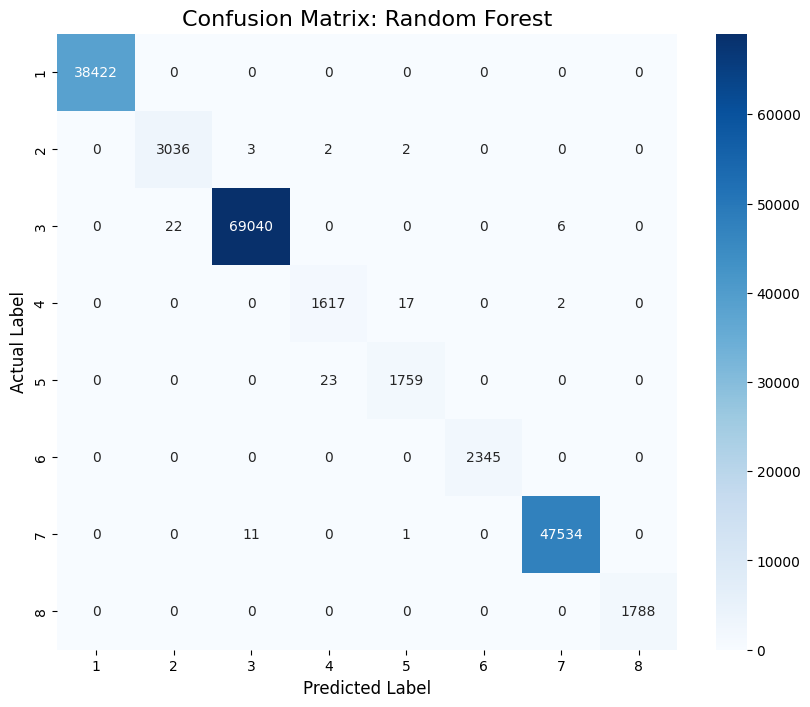


🚀 Training and Evaluating: Decision Tree
   Fitting Decision Tree...
   ✅ Training complete in 24.63 seconds.

📊 Classification Report for Decision Tree:
              precision    recall  f1-score   support

           1       1.00      1.00      1.00     38422
           2       0.99      1.00      0.99      3043
           3       1.00      1.00      1.00     69068
           4       0.98      0.99      0.98      1636
           5       0.99      0.98      0.98      1782
           6       1.00      1.00      1.00      2345
           7       1.00      1.00      1.00     47546
           8       1.00      1.00      1.00      1788

    accuracy                           1.00    165630
   macro avg       0.99      1.00      0.99    165630
weighted avg       1.00      1.00      1.00    165630

   🖼️  Generating Confusion Matrix for Decision Tree...


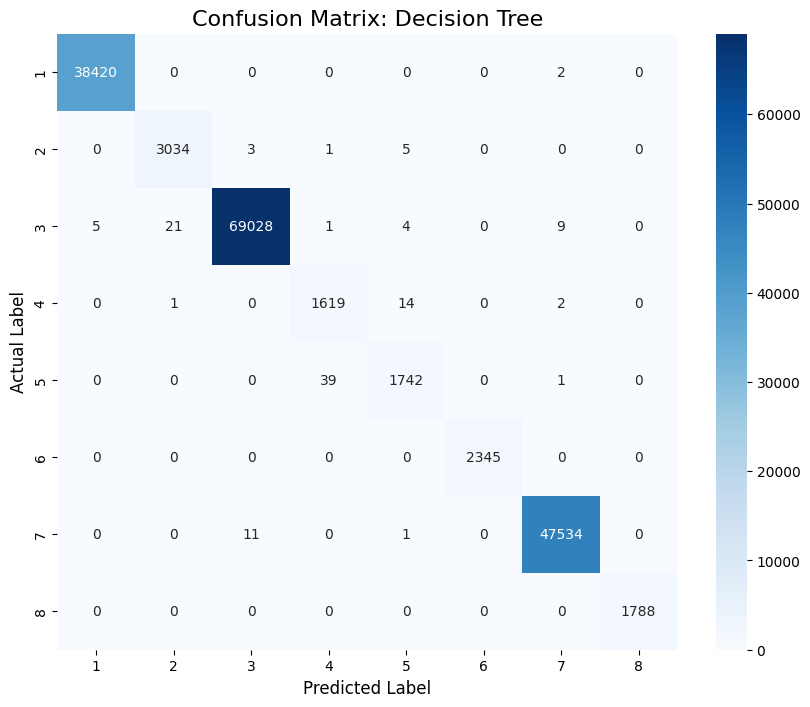


🚀 Training and Evaluating: Gaussian Naive Bayes
   Fitting Gaussian Naive Bayes...
   ✅ Training complete in 0.97 seconds.

📊 Classification Report for Gaussian Naive Bayes:
              precision    recall  f1-score   support

           1       0.83      0.70      0.76     38422
           2       0.07      0.99      0.13      3043
           3       0.99      0.50      0.67     69068
           4       0.88      0.64      0.74      1636
           5       0.53      0.66      0.59      1782
           6       1.00      0.49      0.65      2345
           7       1.00      1.00      1.00     47546
           8       0.56      1.00      0.72      1788

    accuracy                           0.71    165630
   macro avg       0.73      0.75      0.66    165630
weighted avg       0.93      0.71      0.77    165630

   🖼️  Generating Confusion Matrix for Gaussian Naive Bayes...


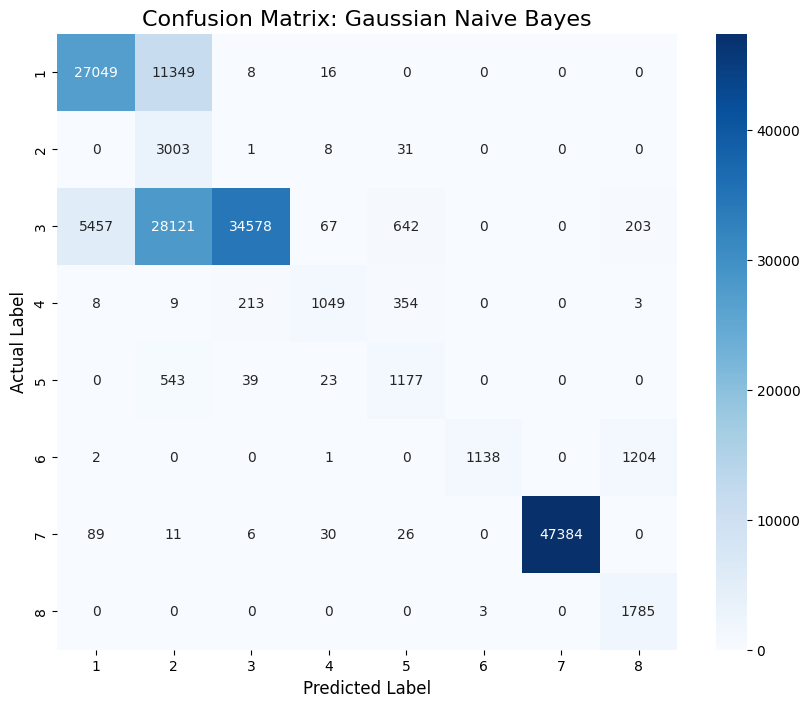



--- All model comparisons are complete. ---


In [14]:
# =====================================================================================
# ========= START: CODE BLOCK FOR TRADITIONAL MODEL COMPARISON ========================
# =====================================================================================

import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n\n\n--- Stage 3: Comparison with Traditional Machine Learning Classifiers ---")

# The data has been prepared in the previous stages. We will use the following variables:
# X_train: X_attack_train_full_df (The full training set for a fair comparison)
# y_train: y_attack_train_full_encoded_np
# X_test:  X_attack_test_df
# y_test:  y_attack_test_encoded_np

# 1. Define the dictionary of models to evaluate
models_to_compare = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    # "Support Vector Machine (SVM)": SVC(kernel='rbf', random_state=42), # WARNING: This will be extremely slow on this dataset. Uncomment if you are prepared to wait.
    "Gaussian Naive Bayes": GaussianNB()
}

# 2. Iterate through each model to train, predict, and evaluate
for model_name, model in models_to_compare.items():
    print(f"\n" + "="*60)
    print(f"🚀 Training and Evaluating: {model_name}")
    print("="*60)

    # Train the model and measure the time
    print(f"   Fitting {model_name}...")
    start_time = time.time()
    # Use the correct variable names from the main script
    model.fit(X_attack_train_full_df, y_attack_train_full_encoded_np)
    end_time = time.time()
    print(f"   ✅ Training complete in {end_time - start_time:.2f} seconds.")

    # Make predictions on the test set
    y_pred = model.predict(X_attack_test_df)

    # Print the classification report with class-wise performance
    print(f"\n📊 Classification Report for {model_name}:")
    print(classification_report(
        y_attack_test_encoded_np,
        y_pred,
        target_names=[str(cls) for cls in ATTACK_CLASS_NAMES],
        zero_division=0
    ))

    # Calculate and plot the confusion matrix
    print(f"   🖼️  Generating Confusion Matrix for {model_name}...")
    cm = confusion_matrix(y_attack_test_encoded_np, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=ATTACK_CLASS_NAMES,
                yticklabels=ATTACK_CLASS_NAMES)
    plt.title(f'Confusion Matrix: {model_name}', fontsize=16)
    plt.ylabel('Actual Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.show()

print("\n\n--- All model comparisons are complete. ---")

# =====================================================================================
# ========= END: CODE BLOCK FOR TRADITIONAL MODEL COMPARISON ==========================
# =====================================================================================


In [1]:
# =====================================================================================
# ========= START: ROBUSTNESS COMPARISON SCRIPT (NOISE INJECTION) =====================
# =====================================================================================
# This script tests how model performance is affected by noise in the training data.
# A more robust, generalizable model will be less affected by noise.

import time
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import torch

print("\n\n\n--- Stage 4: Model Robustness Comparison (Noise Injection Test) ---")
print("Comparing GNN vs. Traditional Models on training data with added noise.")

# =====================================================================================
# 1. Data Preparation
# =====================================================================================
# We use the full training and test sets defined in the 'gnn_bayes_optimized' script.
# X_attack_train_full_df, y_attack_train_full_encoded_np
# X_attack_test_df, y_attack_test_encoded_np

# =====================================================================================
# 2. Define Models and Noise Levels
# =====================================================================================

# Define the levels of noise to add to the training data
# This represents the standard deviation of the noise relative to the data's scale
noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20]

# Dictionary to store the F1 scores for each model at each noise level
results = {
    "Random Forest": [],
    "Decision Tree": [],
    "GNN Bayesian": []
}

# Define the traditional models
traditional_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
}

# =====================================================================================
# 3. Train and Evaluate Traditional Models with Noise
# =====================================================================================

for model_name, model in traditional_models.items():
    print(f"\n--- Evaluating {model_name} ---")
    for noise_level in noise_levels:
        print(f"  Training with noise level: {noise_level*100:.0f}%...")
        
        # Create a noisy version of the training data
        X_train_noisy = X_attack_train_full_df.copy()
        # Add Gaussian noise scaled by the noise_level
        noise = np.random.normal(0, noise_level, X_train_noisy.shape)
        X_train_noisy += noise
        
        # Train the model on the noisy data
        model.fit(X_train_noisy, y_attack_train_full_encoded_np)
        
        # Predict and evaluate on the CLEAN test data
        y_pred = model.predict(X_attack_test_df)
        score = f1_score(y_attack_test_encoded_np, y_pred, average='weighted', zero_division=0)
        
        results[model_name].append(score)
        print(f"  - F1-Score: {score:.4f}")

# =====================================================================================
# 4. Train and Evaluate the GNN Bayesian Model with Noise
# =====================================================================================

print(f"\n--- Evaluating GNN Bayesian Model ---")
best_gnn_lr = best_lr 
OPTIMAL_EPOCHS = 250 # Use a reasonable number of epochs for this comparison

for noise_level in noise_levels:
    print(f"  Training with noise level: {noise_level*100:.0f}%...")
    
    # Create a noisy version of the training data tensor
    X_train_tensor_noisy = X_train_tensor_stage2.clone()
    noise = torch.randn_like(X_train_tensor_noisy) * noise_level
    X_train_tensor_noisy += noise
    
    # The graph structure is based on the original clean data, as we are testing
    # the model's robustness to noisy features, not a corrupted graph.
    
    # Initialize the model
    gnn_model = GNNBayesianIDS(
        in_features=X_train_tensor_stage2.shape[1],
        hidden_size=128,
        num_classes=NUM_ATTACK_CLASSES
    ).to(device)
    optimizer = torch.optim.Adam(gnn_model.parameters(), lr=best_gnn_lr)
    criterion = nn.NLLLoss(reduction='sum')

    # Train the model on the noisy data
    for epoch in range(OPTIMAL_EPOCHS):
        gnn_model.train()
        optimizer.zero_grad()
        # We use the original clean graph but the noisy features
        log_probs, kl_loss = gnn_model(X_train_tensor_noisy, train_edge_index, is_training=True)
        nll_loss = criterion(log_probs, y_train_tensor_stage2)
        total_loss = nll_loss + (kl_loss / X_train_tensor_noisy.shape[0])
        total_loss.backward()
        optimizer.step()

    # Evaluate the model on the CLEAN test data
    gnn_model.eval()
    with torch.no_grad():
        NUM_MC_SAMPLES = 10
        mc_log_probs = []
        for _ in range(NUM_MC_SAMPLES):
            log_probs_sample, _ = gnn_model(X_test_tensor_stage2, test_edge_index, is_training=False)
            mc_log_probs.append(log_probs_sample.unsqueeze(0))

        mean_log_probs = torch.logsumexp(torch.cat(mc_log_probs, dim=0), dim=0) - torch.log(torch.tensor(NUM_MC_SAMPLES, dtype=torch.float)).to(device)
        y_pred_gnn = torch.argmax(mean_log_probs, dim=1).cpu().numpy()
        
        score = f1_score(y_test_tensor_stage2.cpu().numpy(), y_pred_gnn, average='weighted', zero_division=0)
        results["GNN Bayesian"].append(score)
        print(f"  - F1-Score: {score:.4f}")

# =====================================================================================
# 5. Plot the Final Comparison
# =====================================================================================
print("\n\n--- Plotting Robustness to Noise Comparison ---")

plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(12, 8))

for model_name, scores in results.items():
    plt.plot([n * 100 for n in noise_levels], scores, marker='o', linestyle='--', label=model_name, markersize=8)

plt.title('Model Performance vs. Training Data Noise', fontsize=18)
plt.xlabel('Noise Level Added to Training Data (%)', fontsize=14)
plt.ylabel('Weighted F1-Score on Clean Test Set', fontsize=14)
plt.xticks([n * 100 for n in noise_levels])
plt.ylim(0.5, 1.01) # Adjust ylim to better see the performance drop
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='-', linewidth=0.5)
plt.show()

print("\n--- Robustness comparison complete. ---")
# =====================================================================================
# ========= END: ROBUSTNESS COMPARISON SCRIPT =========================================
# =====================================================================================





--- Stage 4: Model Robustness Comparison (Noise Injection Test) ---
Comparing GNN vs. Traditional Models on training data with added noise.

--- Evaluating Random Forest ---
  Training with noise level: 0%...


NameError: name 'X_attack_train_full_df' is not defined